# Visualisation Notebook

This notebook is used to visualise the analytical functions applied on our final dataset.

## Importing Libraries and Setting up Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

df_path = r'G:\Capg_Case_Study\data\processed\CGD_Transformation_Final.csv'
df = pd.read_csv(df_path, parse_dates=['TS'])

print('rows:', len(df))
print(df[['TS','Zone','Flow_std','Pressure','Leak_Alarm']].head())

rows: 6311
                   TS    Zone  Flow_std  Pressure  Leak_Alarm
0 2024-01-01 05:00:00  Zone_B  1066.857      2.53           0
1 2024-01-08 10:05:00  Zone_B  1036.565      6.55           0
2 2024-01-10 20:00:30  Zone_B   230.373      3.31           0
3 2024-01-15 13:00:00  Zone_B   470.926      6.60           0
4 2024-01-18 08:00:00  Zone_B  1064.690      6.60           0


## Hourly Demand Trend

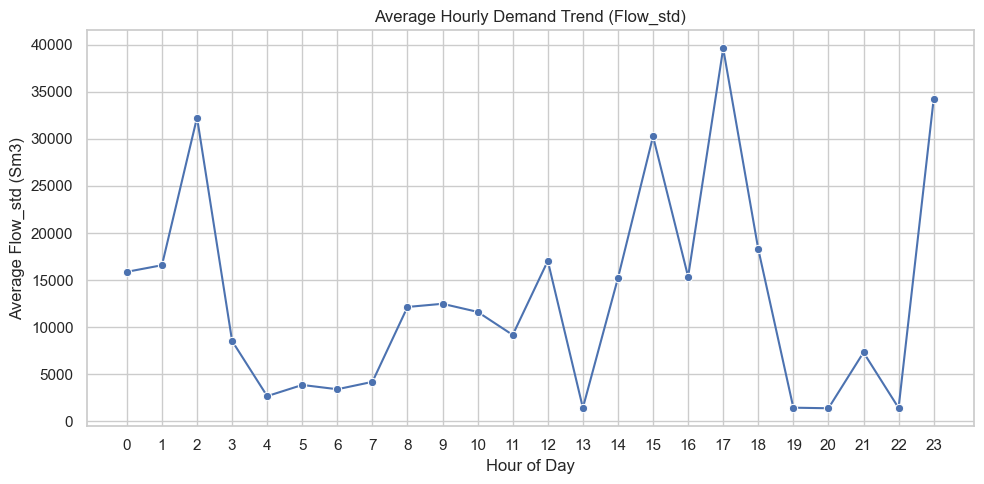

In [4]:
hourly = (
    df.assign(Hour=df['TS'].dt.hour)
      .groupby('Hour')['Flow_std']
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))
sns.lineplot(data=hourly, x='Hour', y='Flow_std', marker='o')
plt.title('Average Hourly Demand Trend (Flow_std)')
plt.xlabel('Hour of Day')
plt.ylabel('Average Flow_std (Sm3)')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

## Zone Consumption Comparison

C:\Users\AYP\AppData\Local\Temp\ipykernel_21444\2064252197.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zone_consumption, x='Zone', y='Flow_std', palette='viridis')


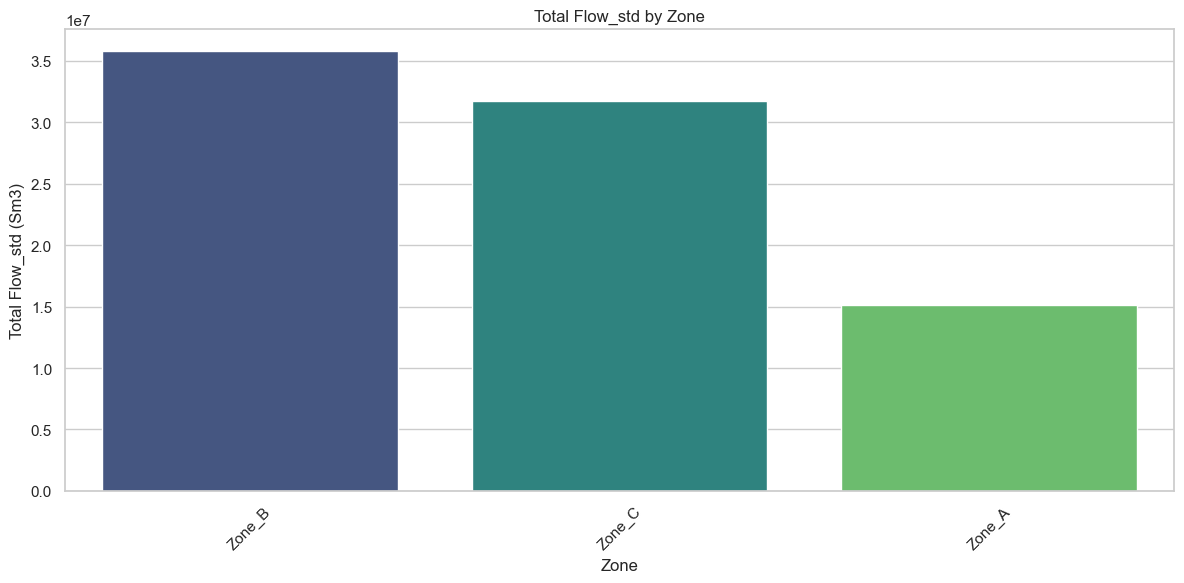

In [5]:
zone_consumption = (
    df.groupby('Zone')['Flow_std']
      .sum()
      .reset_index()
      .sort_values('Flow_std', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(data=zone_consumption, x='Zone', y='Flow_std', palette='viridis')
plt.title('Total Flow_std by Zone')
plt.xlabel('Zone')
plt.ylabel('Total Flow_std (Sm3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## UFG Loss Chart

C:\Users\AYP\AppData\Local\Temp\ipykernel_21444\278635357.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


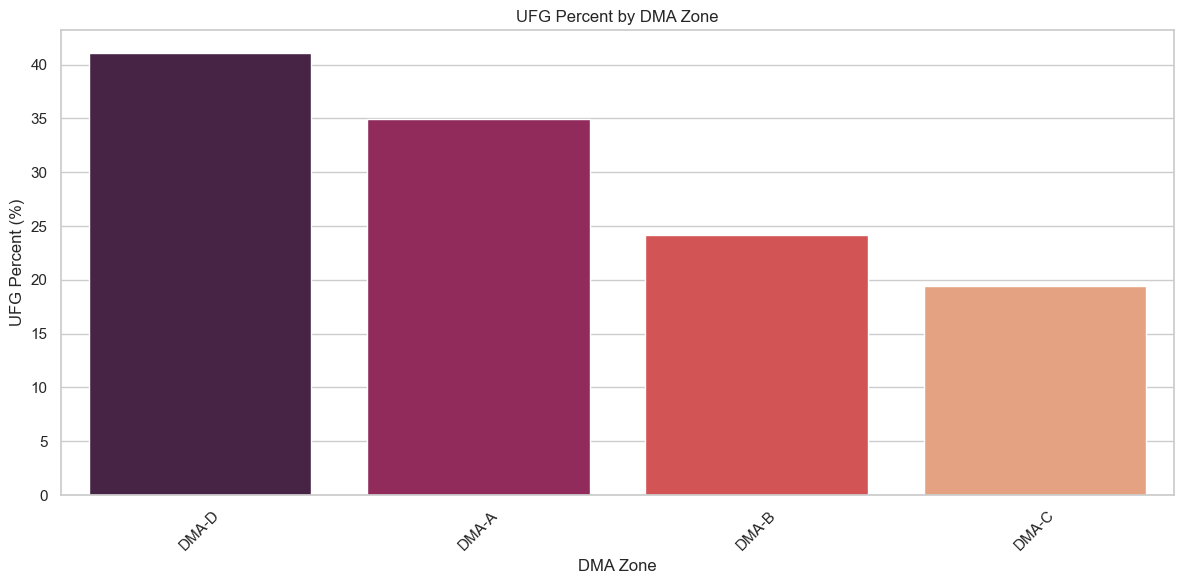

In [6]:
ufg_path = 'data/processed/ufg_dataset.csv'
if os.path.exists(ufg_path):
    ufg_df = pd.read_csv(ufg_path)
else:
    gas_input = df.groupby('DMA_Zone')['Flow_std'].sum().reset_index(name='Gas_Input_Sm3')
    gas_billed = (
        df[df['Is_Billable'] == True]
          .groupby('DMA_Zone')['Flow_std']
          .sum()
          .reset_index(name='Gas_Billed_Sm3')
    )
    ufg_df = gas_input.merge(gas_billed, on='DMA_Zone', how='left').fillna(0)
    ufg_df['UFG_Sm3'] = ufg_df['Gas_Input_Sm3'] - ufg_df['Gas_Billed_Sm3']
    ufg_df['UFG_Percent'] = (
        (ufg_df['UFG_Sm3'] / ufg_df['Gas_Input_Sm3'].replace(0, pd.NA)) * 100
    ).round(2)

ufg_df_sorted = ufg_df.sort_values('UFG_Percent', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(
    data=ufg_df_sorted,
    x='DMA_Zone',
    y='UFG_Percent',
    palette='rocket'
)
plt.title('UFG Percent by DMA Zone')
plt.xlabel('DMA Zone')
plt.ylabel('UFG Percent (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Pressure violation counts

C:\Users\AYP\AppData\Local\Temp\ipykernel_21444\3169980084.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pressure_counts, x='Pressure_Violation', y='Count', palette='magma')


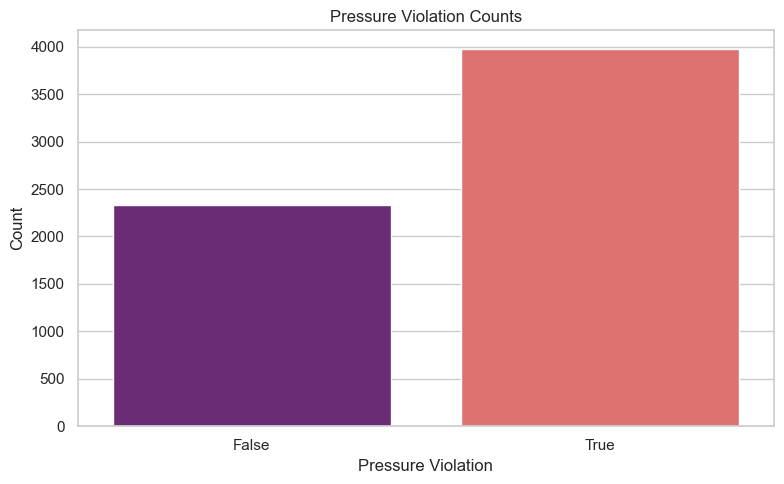

C:\Users\AYP\AppData\Local\Temp\ipykernel_21444\3169980084.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pressure_zone, x='Zone', y='Violation_Count', palette='flare')


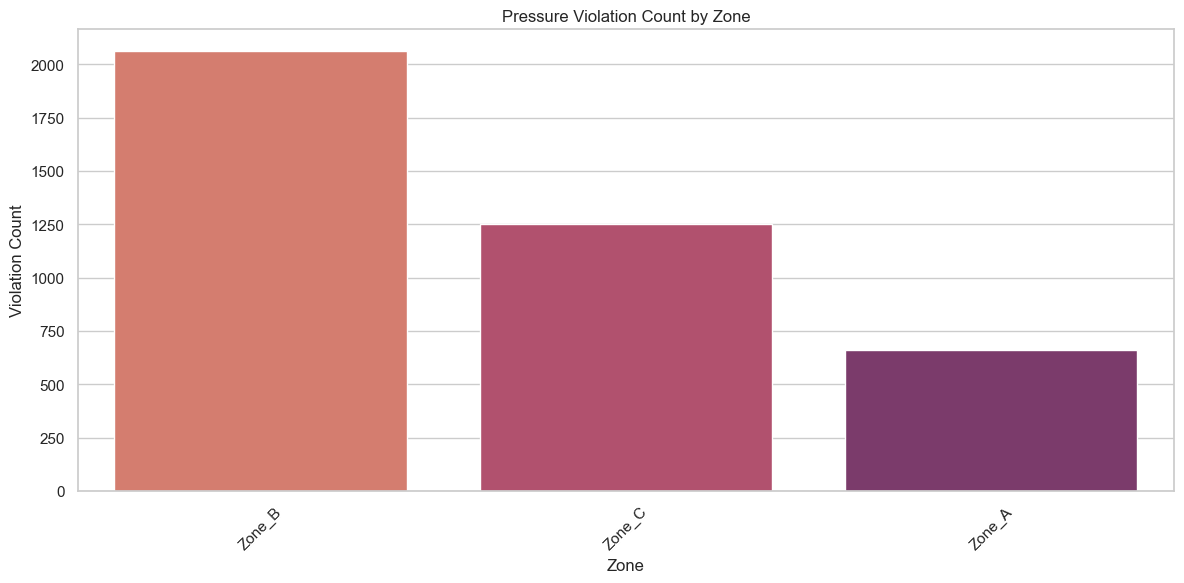

In [7]:
pressure_counts = df['Pressure_Violation'].value_counts(dropna=False).reset_index()
pressure_counts.columns = ['Pressure_Violation', 'Count']

plt.figure(figsize=(8,5))
sns.barplot(data=pressure_counts, x='Pressure_Violation', y='Count', palette='magma')
plt.title('Pressure Violation Counts')
plt.xlabel('Pressure Violation')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

pressure_zone = (
    df[df['Pressure_Violation'] == True]
      .groupby('Zone')
      .size()
      .reset_index(name='Violation_Count')
      .sort_values('Violation_Count', ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(data=pressure_zone, x='Zone', y='Violation_Count', palette='flare')
plt.title('Pressure Violation Count by Zone')
plt.xlabel('Zone')
plt.ylabel('Violation Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Leak Hotspot Map

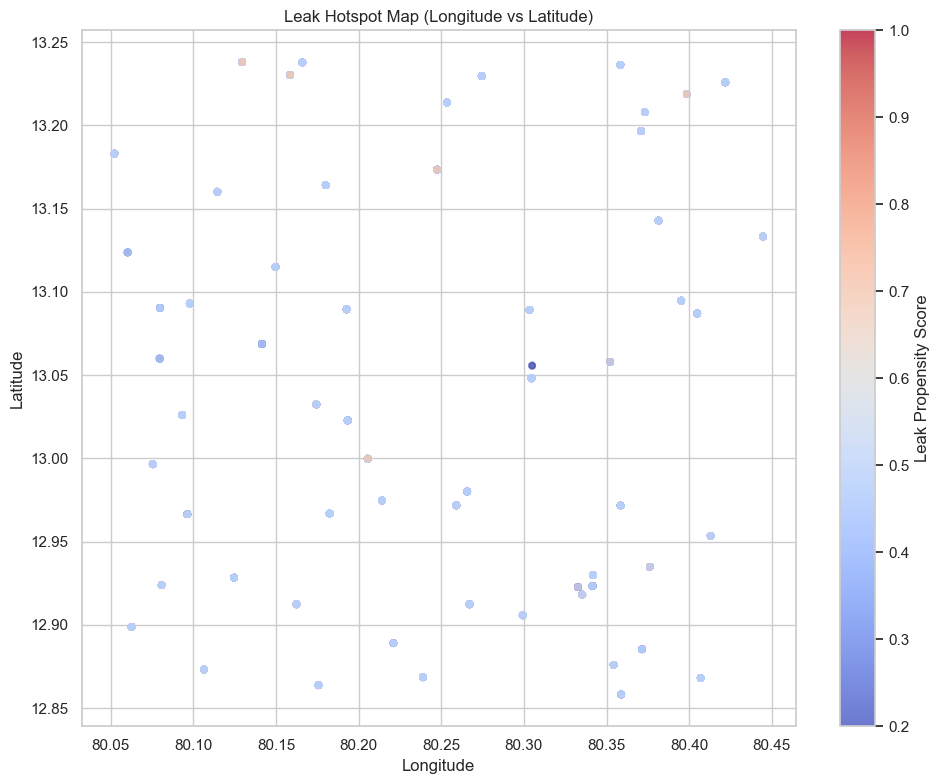

In [8]:
leak_filter = df['Leak_Alarm'].astype(str).str.lower().isin(['true','yes','1'])
if 'Leak_Propensity_Score' in df.columns:
    leak_filter = leak_filter | (df['Leak_Propensity_Score'] >= 0.5)

if {'Latitude','Longitude'}.issubset(df.columns):
    leak_df = df[leak_filter]
    plt.figure(figsize=(10,8))
    scatter = plt.scatter(
        leak_df['Longitude'],
        leak_df['Latitude'],
        c=leak_df.get('Leak_Propensity_Score', 0),
        cmap='coolwarm',
        s=20,
        alpha=0.75
    )
    plt.colorbar(scatter, label='Leak Propensity Score')
    plt.title('Leak Hotspot Map (Longitude vs Latitude)')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.tight_layout()
    plt.show()
else:
    leak_zone = (
        df[leak_filter]
          .groupby('Zone')
          .size()
          .reset_index(name='Leak_Alarm_Count')
          .sort_values('Leak_Alarm_Count', ascending=False)
    )
    plt.figure(figsize=(12,6))
    sns.barplot(data=leak_zone, x='Zone', y='Leak_Alarm_Count', palette='autumn')
    plt.title('Leak Alarm Count by Zone')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Demand forecast

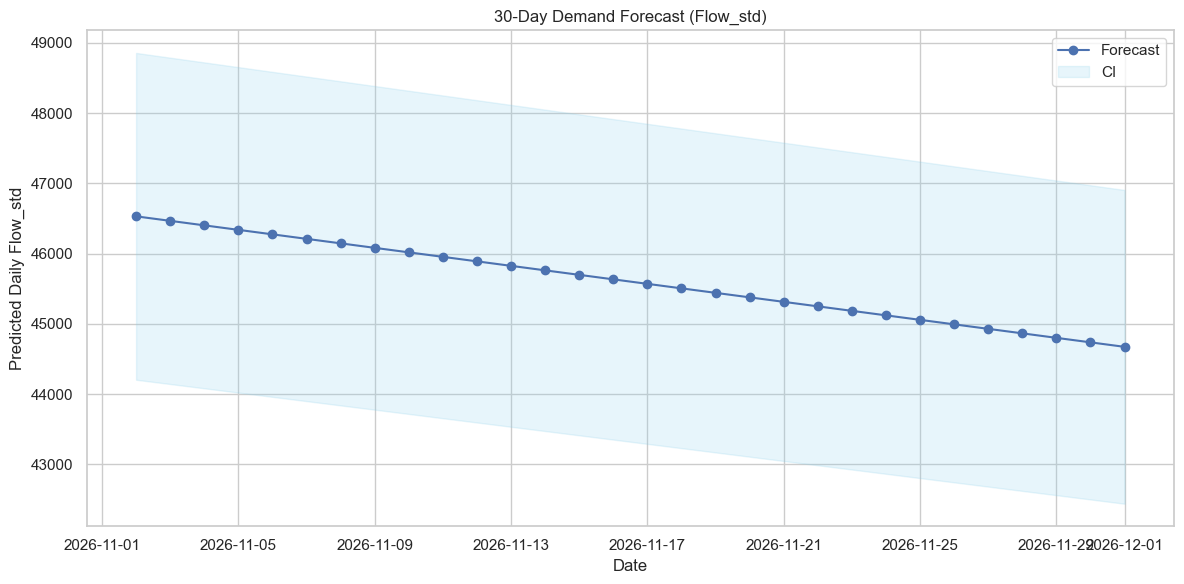

In [13]:
forecast_path = r'G:\Capg_Case_Study\data\analytics_outputs\demand_forecast_30d.csv'
if os.path.exists(forecast_path):
    fc = pd.read_csv(forecast_path, parse_dates=['ds'])
else:
    from src.ml.demand_forecast import generate_30d_demand_forecast
    fc = generate_30d_demand_forecast(df_path, forecast_path)

plt.figure(figsize=(12,6))
plt.plot(fc['ds'], fc['yhat'], marker='o', label='Forecast')
plt.fill_between(fc['ds'], fc['yhat_lower'], fc['yhat_upper'], color='skyblue', alpha=0.2, label='CI')
plt.title('30-Day Demand Forecast (Flow_std)')
plt.xlabel('Date')
plt.ylabel('Predicted Daily Flow_std')
plt.legend()
plt.tight_layout()
plt.show()

#### End